In [1]:
import jax.numpy as jnp
import jax.lax as lax
from jax import jit, tree_util
from functools import partial
from matplotlib import pyplot as plt
import diffrax as dif
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#Formulierung des Anfangswertproblems
f = lambda params, z, u: jnp.array([u[1], params * u[0] + z*1e-4])

z0 = 0.
z1 = 12.
u0 = jnp.array([1., -1e-2])
params = 0.01

In [2]:
@partial(jit, static_argnames=['f', 'n'])
def eigenerSolverV2(params, z0, z1, u0, f, n):
    dz = (z1-z0)/(n-1)

    # Runge-Kutta 4. Ordnung
    def rk4_step(params, z0, dz, u0, f):
        k1 = dz * f(params, z0, u0)
        k2 = dz * f(params, z0 + dz / 2, u0 + k1 / 2)
        k3 = dz * f(params, z0 + dz / 2, u0 + k2 / 2)
        k4 = dz * f(params, z0 + dz, u0 + k3)
        u1 = u0 + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return u1

    def rk4_step_scan(u, x):
        return rk4_step(params, x, dz, u, f), \
            rk4_step(params, x, dz, u, f)

    zs = jnp.linspace(z0, z1, n)
    _, uz = lax.scan(rk4_step_scan, u0, zs[:-1])
    uz = jnp.concatenate([jnp.array([u0]), uz], axis=0)

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(steps=True)
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

@partial(jit, static_argnames=['f', 'n', 'rtol', 'atol']) 
def diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol):

    vector_field = lambda z, y, args: f(args, z, y) #wrapper für reihenfolge
    term = dif.ODETerm(vector_field)
    solver = dif.Dopri5()
    saveat = dif.SaveAt(ts=jnp.linspace(0, z1, n))
    stepsize_controller = dif.PIDController(rtol=rtol, atol=atol)

    sol = dif.diffeqsolve(  term, solver, 
                            t0=z0, t1=z1, dt0=None, y0=u0, args=(params), 
                            saveat=saveat,
                            adjoint=dif.DirectAdjoint(),
                            stepsize_controller=stepsize_controller,
                            max_steps=None)

    zs = sol.ts
    uz = sol.ys

    return uz, zs

f_analytical = lambda z: -1e-2*z + jnp.cosh(0.1*z)

def block_until_ready(pytree):
  return tree_util.tree_map(lambda x: x.block_until_ready(), pytree)

In [3]:
# ns = [5, 10, 20, 40, 60]

# df = pd.DataFrame(columns=['n', 'abw_z1_eigen', 'abw_z1_dopri', 'abw_mean_eigen', 'abw_mean_dopri'])

# for n in ns:
#     uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, 1e-3, 1e-6)

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_z1_eigen = uz_eigen[-1,0] - f_analytical(zs_eigen[-1])
#     abw_z1_dopri = uz_dopri[-1,0] - f_analytical(zs_dopri[-1])
#     abw_mean_eigen = jnp.mean(jnp.abs(uz_eigen[:,0] - f_analytical(zs_eigen)))
#     abw_mean_dopri = jnp.mean(jnp.abs(uz_dopri[:,0] - f_analytical(zs_dopri)))

#     df = pd.concat([df, pd.DataFrame({'n': [n], 'abw_z1_eigen': [abw_z1_eigen], 'abw_z1_dopri': [abw_z1_dopri], 'abw_mean_eigen': [abw_mean_eigen], 'abw_mean_dopri': [abw_mean_dopri]})], ignore_index=True)

#     # # Plot
#     # fig, ax1 = plt.subplots(figsize=(20,10))
#     # plt.title('Test')
#     # ax1.set_xlabel('z/pc')
#     # ax1.set_ylabel('$\Phi / (km/s)^2$')
#     # ax1.scatter(zs_eigen, [u[0] for u in uz_eigen], marker='o', color = 'black', label = 'eigenerSolver')
#     # ax1.scatter(zs_dopri, [u[0] for u in uz_dopri], marker='o', color = 'red', label = 'Dopri5')
#     # zs = jnp.linspace(z0, z1, 100)
#     # ax1.plot(zs, f_analytical(zs), color = 'blue', label = 'Analytische Lösung')
#     # ax1.grid()
#     # ax1.legend()
#     # fig.tight_layout()

# df.to_string('StepSize.txt', col_space=16, justify='left', index=False)

In [4]:
# n = 4
# rtols = [1e-1, 1e-3, 1e-6, 1e-9]
# atol = 0

# df = pd.DataFrame(columns=['rtol', 'abw_eigen', 'abw_dopri', 'abw_mean_eigen', 'abw_mean_dopri'])

# for rtol in rtols:

#     uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol)

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
#     abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
#     abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))

#     df = pd.concat([df, pd.DataFrame({'rtol': [rtol], 'abw_eigen': [tuple(abw_eigen.tolist())], 'abw_dopri': [tuple(abw_dopri.tolist())], 'abw_mean_eigen': [abw_mean_eigen], 'abw_mean_dopri': [abw_mean_dopri]})], ignore_index=True)

#     # Plot
#     # fig, ax1 = plt.subplots(figsize=(20,10))
#     # plt.title('Test')
#     # ax1.set_xlabel('z/pc')
#     # ax1.set_ylabel('$\Phi / (km/s)^2$')
#     # ax1.scatter(zs_eigen, [u[0] for u in uz_eigen], marker='o', color = 'black', label = 'eigenerSolver')
#     # ax1.scatter(zs_dopri, [u[0] for u in uz_dopri], marker='o', color = 'red', label = 'Dopri5')
#     # zs = jnp.linspace(z0, z1, 100)
#     # ax1.plot(zs, f_analytical(zs), color = 'blue', label = 'Analytische Lösung')
#     # ax1.grid()
#     # ax1.legend()
#     # fig.tight_layout()

# df.to_csv('rtol.csv', sep=',', index=False)

In [5]:
# n = 4
# rtol = 0
# atols = [1e-1, 1e-3, 1e-6, 1e-9]

# df = pd.DataFrame(columns=['atol', 'abw_eigen', 'abw_dopri', 'abw_mean_eigen', 'abw_mean_dopri'])

# for atol in atols:

#     uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
#     uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol)

#     uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
#     zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

#     abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
#     abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
#     abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
#     abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))

#     df = pd.concat([df, pd.DataFrame({'atol': [atol], 'abw_eigen': [tuple(abw_eigen.tolist())], 'abw_dopri': [tuple(abw_dopri.tolist())], 'abw_mean_eigen': [abw_mean_eigen], 'abw_mean_dopri': [abw_mean_dopri]})], ignore_index=True)

#     # Plot
#     # fig, ax1 = plt.subplots(figsize=(20,10))
#     # plt.title('Test')
#     # ax1.set_xlabel('z/pc')
#     # ax1.set_ylabel('$\Phi / (km/s)^2$')
#     # ax1.scatter(zs_eigen, [u[0] for u in uz_eigen], marker='o', color = 'black', label = 'eigenerSolver')
#     # ax1.scatter(zs_dopri, [u[0] for u in uz_dopri], marker='o', color = 'red', label = 'Dopri5')
#     # zs = jnp.linspace(z0, z1, 100)
#     # ax1.plot(zs, f_analytical(zs), color = 'blue', label = 'Analytische Lösung')
#     # ax1.grid()
#     # ax1.legend()
#     # fig.tight_layout()

# df.to_csv('atol.csv', sep=',', index=False)

In [6]:
# n = 11
# rtol = 0
# atol = 1e-6

# df = pd.DataFrame(columns=['abw_mean_eigen', 'abw_mean_dopri', 'abw_max_eigen', 'abw_max_dopri'])

# print('eigenerSolverV2')
# %time block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))
# %timeit block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))

# print('Dopri5')
# %time block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol))
# %timeit block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol))

# uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
# uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol)

# uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
# zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

# abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
# abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
# abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
# abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
# abw_max_eigen = jnp.max(jnp.abs(abw_eigen))
# abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

# df = pd.concat([df, pd.DataFrame({'abw_mean_eigen': [abw_mean_eigen], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_eigen': [abw_max_eigen], 'abw_max_dopri': [abw_max_dopri]})], ignore_index=True)

# # Plot
# fig, ax1 = plt.subplots(figsize=(20,10))
# plt.title('Test')
# ax1.set_xlabel('z/pc')
# ax1.set_ylabel('$\Phi / (km/s)^2$')
# ax1.scatter(zs_eigen, [u[0] for u in uz_eigen], marker='o', color = 'black', label = 'eigenerSolver')
# ax1.scatter(zs_dopri, [u[0] for u in uz_dopri], marker='o', color = 'red', label = 'Dopri5')
# zs = jnp.linspace(z0, z1, 100)
# ax1.plot(zs, f_analytical(zs), color = 'blue', label = 'Analytische Lösung')
# ax1.grid()
# ax1.legend()
# fig.tight_layout()

# df.to_string('comparableparams.txt', col_space=16, justify='left', index=False)


In [7]:
ns = [5, 10, 20, 50, 100, 200, 500, 750, 1000, 1500, 2000]

df_e = pd.DataFrame(columns=['n', 'abw_mean_eigen', 'abw_max_eigen', 't_mean', 't_std'])

for n in ns:
    uz_eigen, zs_eigen = eigenerSolverV2(params, z0, z1, u0, f, n)
    t = %timeit -o block_until_ready(eigenerSolverV2(params, z0, z1, u0, f, n))

    abw_eigen = jnp.array([uz_eigen[i,0] - f_analytical(zs_eigen[i]) for i in range(n)])
    abw_mean_eigen = jnp.mean(jnp.abs(abw_eigen))
    abw_max_eigen = jnp.max(jnp.abs(abw_eigen))

    df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)

df_e.to_string('benchmark_eigen.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

9.07 µs ± 329 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_43152\4261186177.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_e = pd.concat([df_e, pd.DataFrame({'n': [n], 'abw_mean_eigen': [abw_mean_eigen], 'abw_max_eigen': [abw_max_eigen], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


9.85 µs ± 852 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.84 µs ± 799 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.87 µs ± 198 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
11.6 µs ± 310 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
13.6 µs ± 324 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
19.4 µs ± 98.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
23.6 µs ± 606 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
28.4 µs ± 1.2 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
38.2 µs ± 765 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
47.3 µs ± 1.25 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


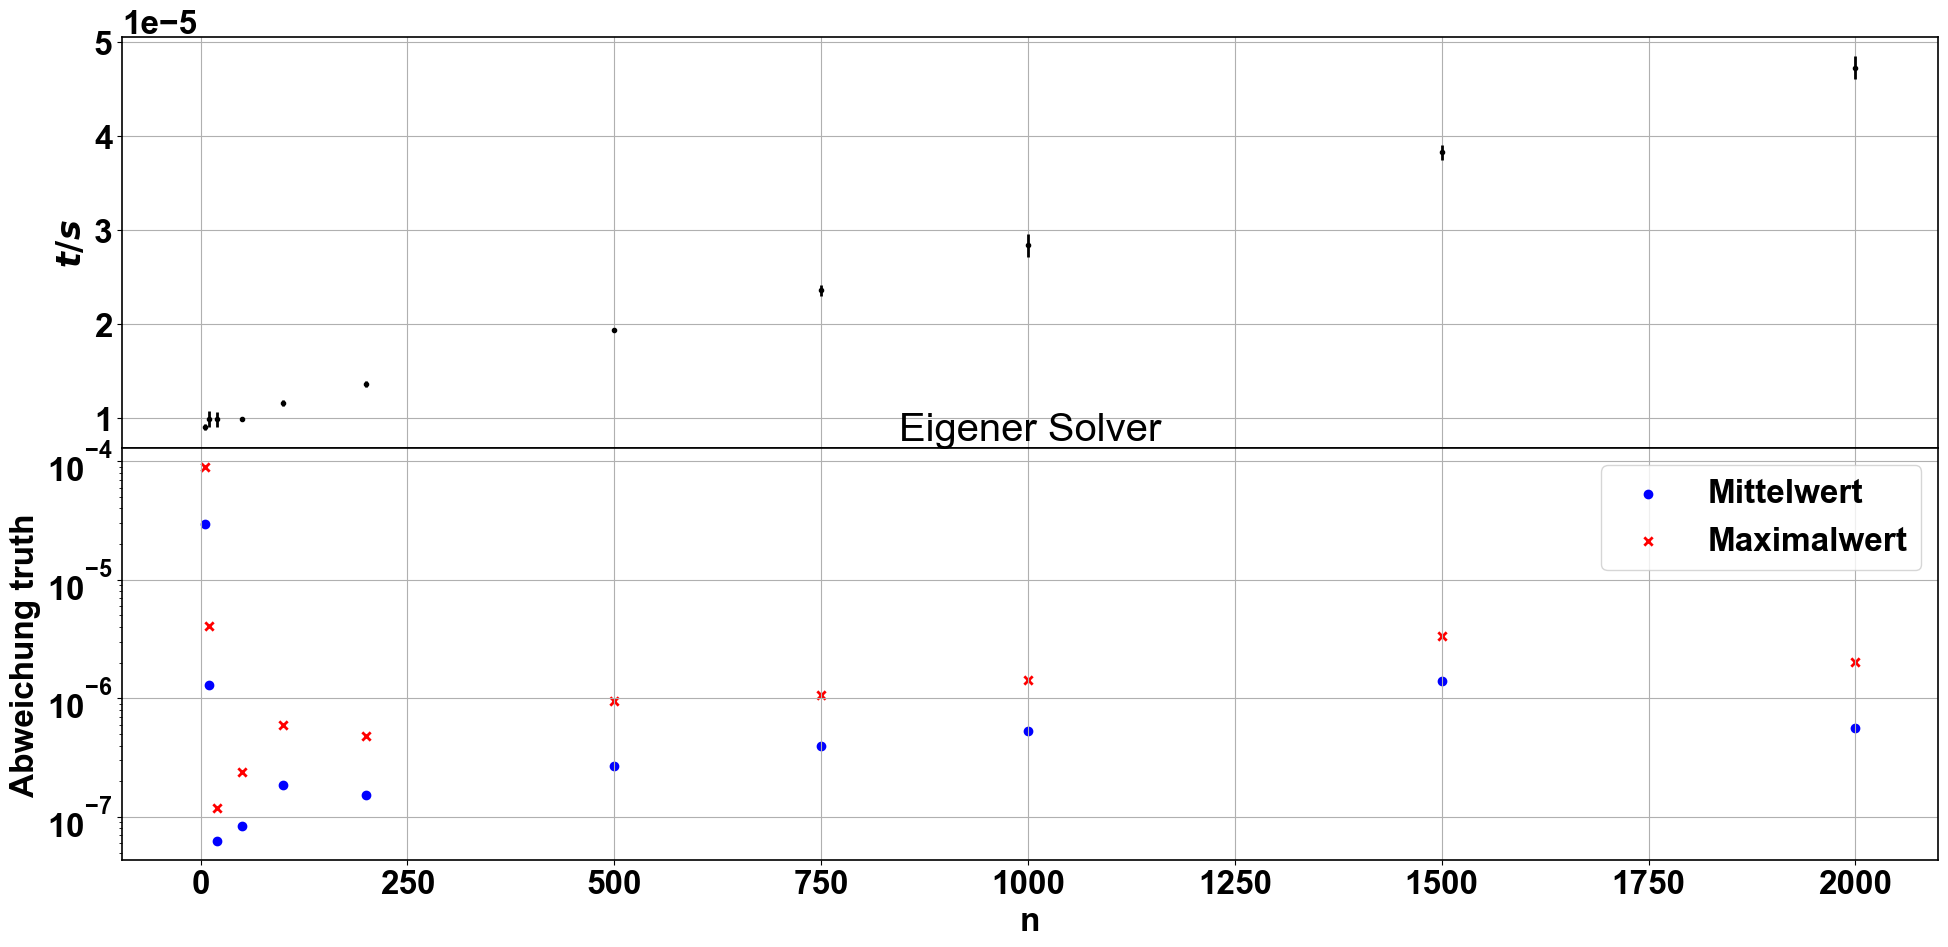

In [8]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Eigener Solver')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_e['n'], df_e['t_mean'], yerr=df_e['t_std'], color='black', fmt = '.')
ax[0].grid()
#ax[1].set_xscale('log')
ax[1].set_xlabel('n')
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_e['n'], df_e['abw_mean_eigen'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_e['n'], df_e['abw_max_eigen'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [9]:
rtol = 0
atols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]

df_d = pd.DataFrame(columns=['atol', 'abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for atol in atols:
    uz_dopri, zs_dopri = diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5(params, z0, z1, u0, f, n, rtol, atol))

    uz_dopri = uz_dopri[~jnp.isinf(uz_dopri).any(axis=1)]
    zs_dopri = zs_dopri[~jnp.isinf(zs_dopri)]

    abw_dopri = jnp.array([uz_dopri[i,0] - f_analytical(zs_dopri[i]) for i in range(len(zs_dopri))])
    abw_mean_dopri = jnp.mean(jnp.abs(abw_dopri))
    abw_max_dopri = jnp.max(jnp.abs(abw_dopri))

    df_d = pd.concat([df_d, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_d.to_string('benchmark_dopri.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)


199 µs ± 3.72 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_43152\856258365.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_d = pd.concat([df_d, pd.DataFrame({'atol':[atol], 'abw_mean_dopri': [abw_mean_dopri], 'abw_max_dopri': [abw_max_dopri], 'n': [len(zs_dopri)], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


201 µs ± 3.49 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
203 µs ± 2.86 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
202 µs ± 9.99 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
183 µs ± 10.8 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
182 µs ± 3.16 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
176 µs ± 1.61 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
178 µs ± 3.06 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
177 µs ± 961 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


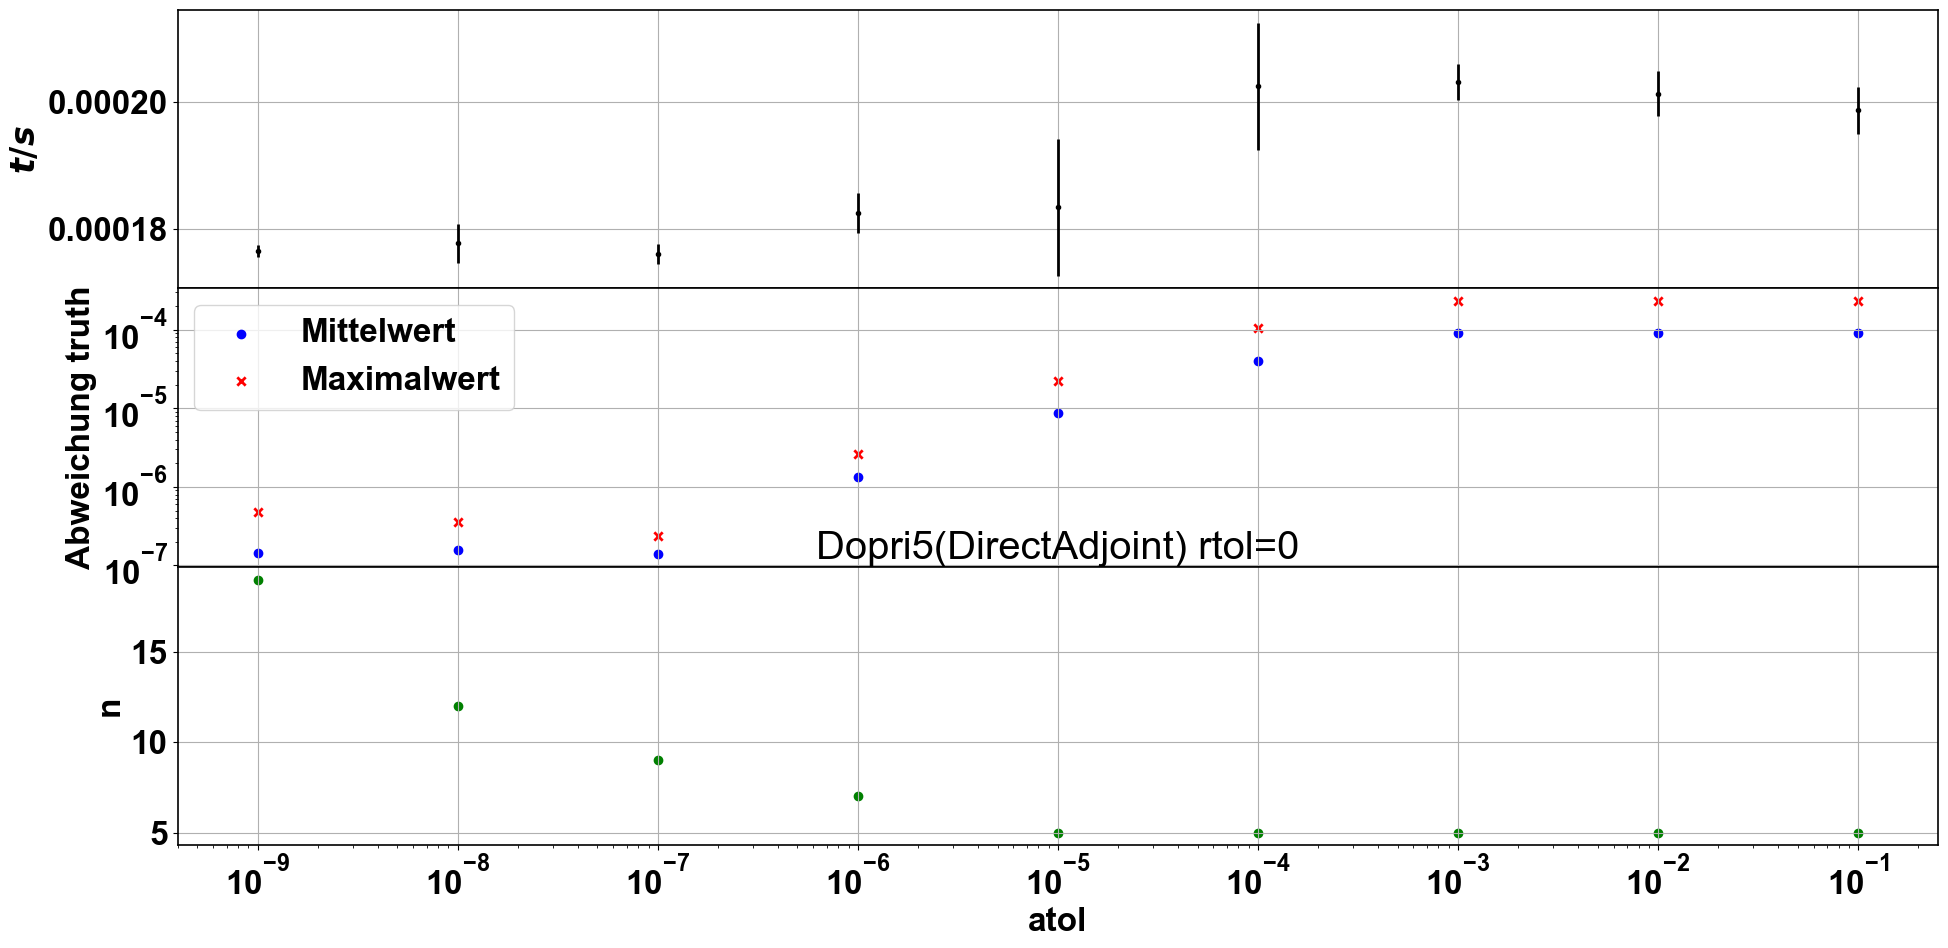

In [10]:
# Plot
fig, ax = plt.subplots(3,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_d['atol'], df_d['t_mean'], yerr=df_d['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_d['atol'], df_d['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_d['atol'], df_d['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[2].set_xlabel('atol')
ax[2].set_xscale('log')
ax[2].set_ylabel('n')
ax[2].scatter(df_d['atol'], df_d['n'], color='green', marker='o')
ax[2].grid()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [11]:
ns = [5, 10, 50, 100, 500, 1000, 2000]
rtol = 0
atol = 1e-6

df_dn = pd.DataFrame(columns=['abw_mean_dopri', 'abw_max_dopri', 'n', 't_mean', 't_std'])

for n in ns:
    uz_doprin, zs_doprin = diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol)
    t = %timeit -o block_until_ready(diffraxDopri5n(params, z0, z1, u0, f, n, rtol, atol))

    abw_doprin = jnp.array([uz_doprin[i,0] - f_analytical(zs_doprin[i]) for i in range(n)])
    abw_mean_doprin = jnp.mean(jnp.abs(abw_doprin))
    abw_max_doprin = jnp.max(jnp.abs(abw_doprin))

    df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)



df_dn.to_string('benchmark_doprin.txt', col_space=16, justify='left', index=False, float_format = '{:.2e}'.format)

171 µs ± 1.2 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_43152\450366965.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dn = pd.concat([df_dn, pd.DataFrame({'abw_mean_dopri': [abw_mean_doprin], 'abw_max_dopri': [abw_max_doprin], 'n': [n], 't_mean': [t.average], 't_std': [t.stdev]})], ignore_index=True)


173 µs ± 941 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
173 µs ± 982 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
173 µs ± 2.44 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
175 µs ± 891 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
180 µs ± 494 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
188 µs ± 569 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


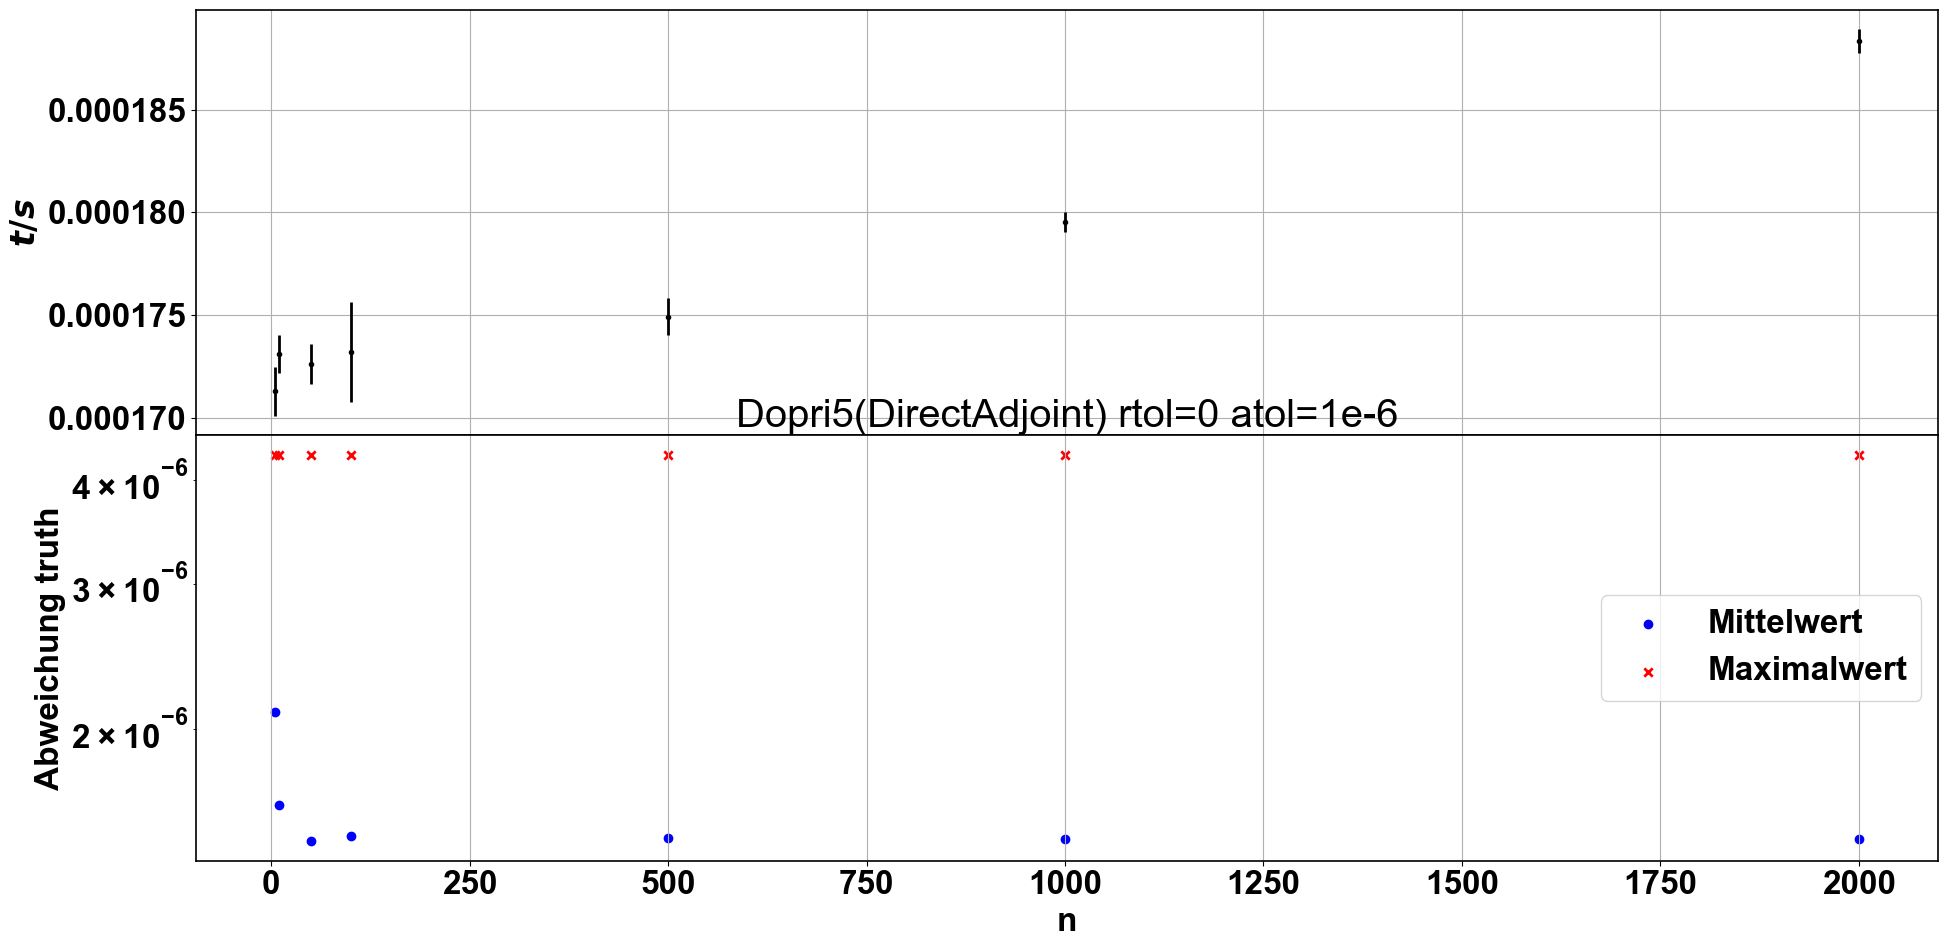

In [12]:
# Plot
fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [3, 3]})
plt.title('Dopri5(DirectAdjoint) rtol=0 atol=1e-6')
ax[0].set_ylabel('$t/s$')
#ax[0].set_yscale('log')
ax[0].errorbar(df_dn['n'], df_dn['t_mean'], yerr=df_dn['t_std'], color='black', fmt = '.')
ax[0].grid()
ax[1].set_ylabel('Abweichung truth')
ax[1].set_yscale('log')
ax[1].scatter(df_dn['n'], df_dn['abw_mean_dopri'], color='blue', label='Mittelwert', marker='o')
ax[1].scatter(df_dn['n'], df_dn['abw_max_dopri'], color='red', label='Maximalwert', marker='x')
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel('n')
#ax[1].set_xscale('log')
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)